# Syria Telecom's Customer Churn Prediction
## Phase 3 Machine Learning Project

**Author:** Kelvin Ngumo  
**Date:** February 2026  
**Stakeholder:** Syria Telecom's Retention & Marketing Department

___

### <u>**Project Overview**</u>
The primary goal of this project is to build a classifier that predicts whether a customer will stop doing business with Syria Telecom's. 

### <u>**The Business Problem**</u>
In the telecommunications industry, acquiring a new customer is significantly more expensive than retaining an existing one. For Syria Telecom's, high churn rates lead to:
* **Revenue Loss:** Immediate loss of monthly subscription fees and usage charges.
* **Increased Marketing Costs:** High spend required to replace lost customers.

### <u>**Objective**</u>
By identifying "at-risk" customers through predictable patterns in usage and service interactions, Syria Telecom's can proactively offer retention incentives (discounts, plan upgrades) to reduce churn and protect the bottom line.
___

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# reading the dataset
churn_data = pd.read_csv('bigml_59c28831336c6604c800002a.csv')

In [2]:
churn_data.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

### <u>**Data Source**</u>
The dataset contains 3,333 records of customer activity, including usage minutes, service calls, and plan types.
<br>The dataset also contains 21 active columns (Features) that contain no missing Values.


### <u>**Key Features for Analysis**</u>
* **Target:** `churn` (Boolean)
* **Predictors:** * `customer service calls`: Indicators of customer satisfaction.
    * `total day charge` & `total intl charge`: Financial pressure points.
    * `international plan`: Potential indicator of specific customer needs.

## <u>Exploratory Data Analysis (EDA)</u>

In [7]:
# identifying which features are numerical
numerical_features = churn_data.select_dtypes(include=['int64', 'float64','bool']).columns

numerical_features

Index(['account length', 'area code', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [6]:
# identifying which columns are categorical
categorical_features = churn_data.select_dtypes(include=['object']).columns

categorical_features

Index(['state', 'phone number', 'international plan', 'voice mail plan'], dtype='object')

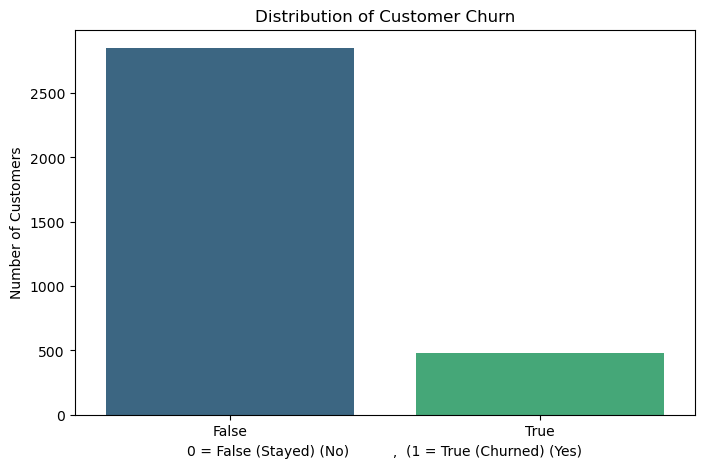

Churn Rate: 14.49%
Retention Rate: 85.51%


In [25]:
# Calculate percentages
churn_counts = churn_data['churn'].value_counts()
churn_pct = churn_data['churn'].value_counts(normalize=True) * 100

# Plotting
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=churn_data, hue='churn', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn')
plt.xlabel('0 = False (Stayed) (No)          ,  (1 = True (Churned) (Yes)')
plt.ylabel('Number of Customers')
plt.show()

print(f"Churn Rate: {churn_pct.iloc[1]:.2f}%")
print(f"Retention Rate: {churn_pct.iloc[0]:.2f}%")

### Visual Summary: Customer Churn Distribution
The bar chart above visualizes the distribution of the target variable , churn. This provides a baseline understanding of the class balance within the dataset.
<br>`Insight`: The dataset is imbalanced, with a significantly higher number of retained customers compared to those who churned. This imbalance should be taken into account when selecting evaluation metrics.

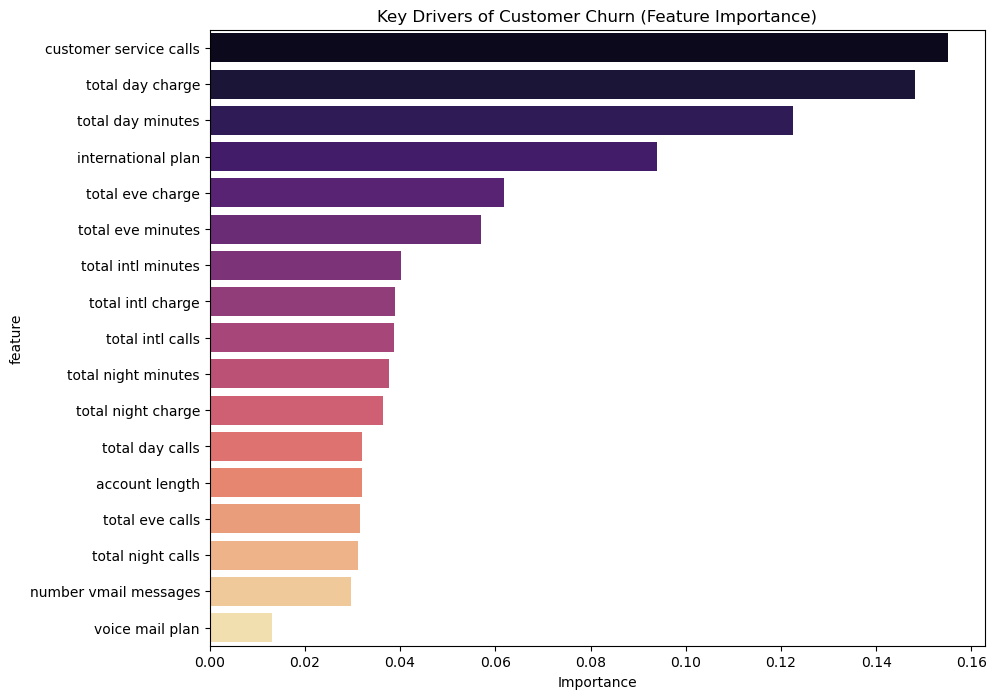

In [18]:
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

# Preparing a numeric version of the dataset for correlation analysis
df_corr = churn_data.copy()

# Convert target to int for correlation analysis
df_corr['churn'] = df_corr['churn'].astype(int)

# Map binary categorical predictors to numeric
binary_mappings = {'yes': 1, 'no': 0}
df_corr['international plan'] = df_corr['international plan'].map(binary_mappings)
df_corr['voice mail plan'] = df_corr['voice mail plan'].map(binary_mappings)

# Drop non-predictive columns
X_drop = df_corr.drop(columns=['churn', 'state', 'area code', 'phone number'])
y_drop = df_corr['churn']

# Balance classes by using Upsampling churners.
df_majority = df_corr[df_corr['churn'] == 0]
df_minority = df_corr[df_corr['churn'] == 1]
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=254)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

X_balanced = df_balanced.drop(columns=['churn','state', 'area code', 'phone number'])
y_balanced = df_balanced['churn']

## Train Models and extract important features
rf = RandomForestClassifier(n_estimators=100, random_state=254)
rf.fit(X_balanced, y_balanced)

## Create a dataframe for visualization
feat_importances = pd.DataFrame({'feature': X_balanced.columns, 'Importance': rf.feature_importances_})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)


# Plot the Results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='feature', data=feat_importances, hue='feature', palette='magma', legend=False)
plt.title('Key Drivers of Customer Churn (Feature Importance)')
plt.show()


### Visual Summary

From the above code cell, we run a Random Forest, for feature importance tells us which variables actually carry the most "predictive weight" when a model is trying to guess if a customer will leave.  <br>we will then follow by running logistic Regression which will tell us exactly how much the probability of churn changes when a specific behavior increases.

## <u>Preprocessing:</u> 